# Эмпирический Байес

Мы познакомились уже с большим количеством моделей и в каждой из них были те или иные гиперпараметры. От них существенно зависит результат работы моделей. На подбор гиперпараметров часто приходится тратить довольно много времени.

Эмпирический Байес даёт нам ответ на то, как выбрать гиперпараметры оптимальным образом. 

Для примера рассмотрим линейную регрессию.

Мы строили модель: $p(y|\overline{x},\overline{w})=N(y|\overline{w}^\top\overline{x},\sigma^2)$ с априорным распределением параметров $p(\overline{w})=N(\overline{w}|\overline{0},\sigma_0^2E)$.

По теореме Байеса мы получали логарифм апостериорного распределения:

$$\log p(\overline{w}|\overline{y},X)=\text{const}-\frac{1}{2\sigma^2}\sum_n(y_n-\overline{w}^\top\overline{x}_n)^2-\frac{1}{2\sigma_0^2}\overline{w}^\top\overline{w}.$$

Можно переобозначить параметры $\beta=\frac{1}{\sigma^2}$, $\alpha=\frac{1}{\sigma_0^2}$. Тогда $\frac{\alpha}{\beta}$ это в точности коэффициент регуляризации в линейной регрессии. 

Мы бы хотели выбрать коэффициент регуляризации оптимальным образом. Параметры $\alpha$ и $\beta$ задают множества моделей, а не какую-то конкретную. Поэтому выбрать эти параметры мы можем через максимизацию **маргинального правдоподобия**:

$$p(D|\alpha,\beta)\rightarrow \max_{\alpha,\beta}$$


После решения описанной задачи мы получим следующие итеративные формулы:

$$\alpha^{(k+1)}=\frac{1}{\overline{\mu}^\top\overline{\mu}}\sum_i\frac{\lambda_i}{\lambda_i+\alpha^{(k)}},$$

$$\beta^{(k+1)}=\frac{N-\sum_i\frac{\lambda_i}{\lambda_i+\alpha^{(k)}}}{\sum_n(y_n-\overline{x}_n^\top\overline{\mu})^2},$$

где $A=\Sigma_N^{-1}=\beta X^\top X+\alpha E,\;\; \overline{\mu}=\overline{\mu}_N=\beta A^{-1}X^\top \overline{y}$, а $\lambda_i$ $-$ собственные числа матрицы $\beta(X^\top X)$.

А теперь давайте посмотрим как это работает на практике.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import linear_model
import scipy

figsize = (15,8)

In [2]:
## Исходная функция
orig = lambda x : np.sin(x)

## X-координаты точек данных
# xd = np.arange(-1.5, 2, 7/60)
xd = np.array([-3, -2, -1, -0.5, 0, 0.5, 1, 1.5, 2.5, 3, 4]) / 2
# xd = np.array([-3, -2, -1, -0.5, 0, 0.5, 1, 1.5, 2.5, 3, 4]) / 2
num_points = len(xd)

## Данные
data = orig(xd) + np.random.normal(0, .25, num_points)

## Для рисования
xs = np.arange(xd[0]-1.5, xd[-1]+1.5, 0.01)

## Обучаем модель с регуляризацией
def train_model(xs, ys, alpha=0, use_lasso=False):
    if alpha == 0:
        return linear_model.LinearRegression(fit_intercept=True).fit( xs, ys )
    else:
        if use_lasso:
            return linear_model.Lasso(alpha=alpha, fit_intercept=True).fit( xs, ys )
        else:
            return linear_model.Ridge(alpha=alpha, fit_intercept=True).fit( xs, ys )

[0.65319376]
[ 0.9005974  -0.04129651 -0.09392566]
[ -1.77238685  -1.31454154  25.54296316   5.91706107 -70.54929235
   7.00137431  63.29888762 -18.47369951 -16.33948202   6.36031173]


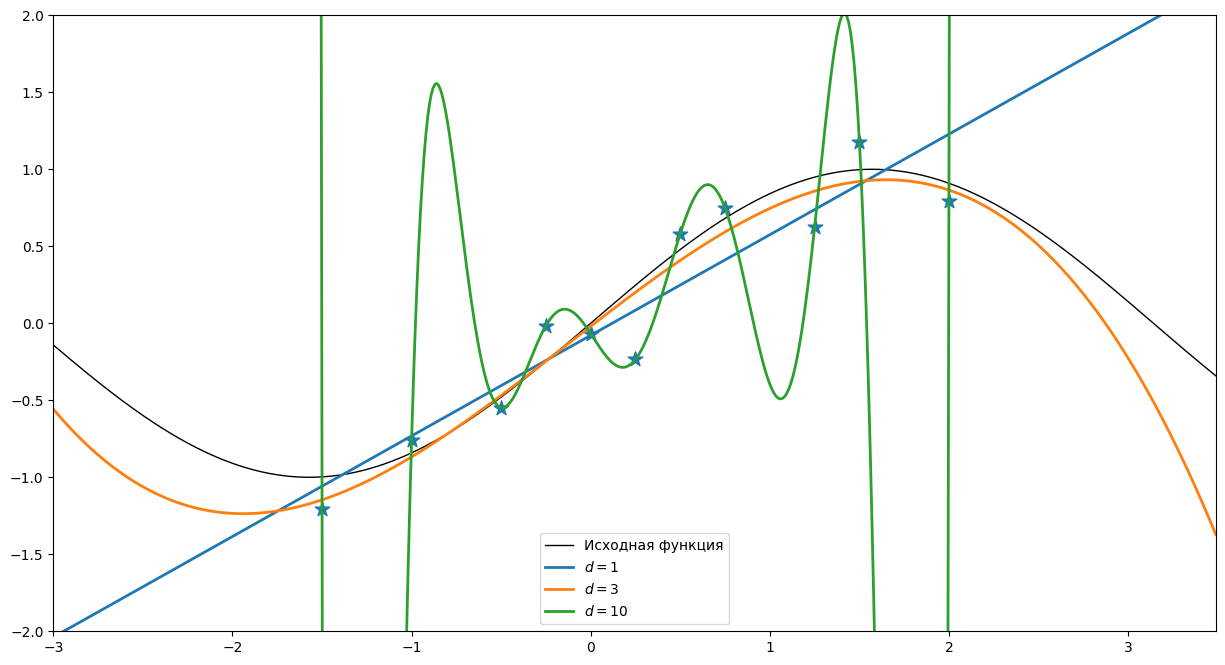

In [3]:
## Выделение полиномиальных признаков
xs_d = np.vstack([xs ** i for i in range(1, num_points+1)]).transpose()
xd_d = np.vstack([xd ** i for i in range(1, num_points+1)]).transpose()

## Какие степени многочлена будем обучать и рисовать
set_of_powers = [ 1, 3, 10 ]

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.set_xlim((xs[0], xs[-1]))
ax.set_ylim((-2, 2))
ax.scatter(xd, data, marker='*', s=120)
ax.plot(xs, orig(xs), linewidth=1, label="Исходная функция", color="black")

for d in set_of_powers:
    if d == 0:
        print(np.mean(data))
        ax.hlines(np.mean(data), xmin=xs[0], xmax=xs[-1], label="$d=0$", linestyle="dashed")
    else:
        cur_model = train_model( xd_d[:, :d], data, alpha=0.0 )
        print(cur_model.coef_)
        ax.plot(xs, cur_model.predict( xs_d[:, :d] ), linewidth=2, label="$d=%d$" % d)

ax.legend(loc="lower center")

А теперь перейдём к обучению Эмпирического Байеса

In [4]:
## Порождает матрицу признаков в явном виде
def get_X(d):
    return np.hstack([np.ones(xd_d[:, :d].shape[0]).reshape(-1, 1), xd_d[:, :d]])

## Байесовское обновление mu_n и sigma_n
def bayesian_update(mu, Sigma, X, t, beta=4):
    Sigma_inv = np.linalg.inv(Sigma)
    Sigma_n_inv = Sigma_inv + beta * X.T.dot(X)
    Sigma_n = np.linalg.inv(Sigma_n_inv)
    mu_n = Sigma_n.dot( Sigma_inv.dot(mu.T) + beta * X.T.dot(t) )
    return mu_n, Sigma_n

def log_marginal_likelihood(X, t, alpha, beta):
    N, M = X.shape
    mu, sigma = bayesian_update(np.zeros(M), (1/alpha) * np.identity(M), X, t, beta=beta)
    A = np.linalg.inv(sigma)
    return 0.5 * ( M * np.log(alpha) + N * np.log(beta) - \
                  np.log(np.linalg.det(A)) - \
                  beta * np.sum((t - X.dot(mu)) ** 2) - \
                  alpha * np.sum(mu ** 2) - \
                  N * np.log(2 * np.pi) )

def lr_log_marginal(xx, t, d, alpha=0.001, beta=4):
    return log_marginal_likelihood(get_X(d), t, alpha, beta)

## Одна итерация эмпирического Байеса
def empirical_iteration(X, t, XtX, XtT, lambdas, alpha, beta):
    N, d = X.shape
    cur_lambdas = beta * lambdas
    gamma = np.sum(cur_lambdas / (alpha + cur_lambdas))
    A = beta * XtX + alpha * np.identity(d)
    mu = beta * np.linalg.inv(A).dot(XtT)
    a = gamma / np.sum(mu ** 2)
    b = (N - gamma) / np.sum( (t - X.dot(mu)) ** 2)
    return a, b

## Обучаем эмпирический Байес
def fit_eb(X, t, max_iter=400, eps=0.01):
    XtX = X.T.dot(X)
    XtT = X.T.dot(t)
    lambdas = np.linalg.eigvalsh(XtX)
    alpha_0, beta_0 = 1, 1
    alpha, beta = [alpha_0], [beta_0]
    logmargs = [log_marginal_likelihood(X, t, alpha=alpha_0, beta=beta_0)]
    for _ in range(max_iter):
        a, b = empirical_iteration(X, t, XtX, XtT, lambdas, alpha[-1], beta[-1])
        alpha.append(a)
        beta.append(b)
        logmargs.append(log_marginal_likelihood(X, t, alpha=a, beta=b))
        if np.isclose(alpha[-1], alpha[-2], eps) and np.isclose(beta[-1], beta[-2], eps):
            break
    return alpha, beta, logmargs

Теперь мы можем обучить гиперпараметры:

In [5]:
d1 = 9
alphas, betas, lms = fit_eb(get_X(d1), data)

In [6]:
print(alphas)
print(betas)

[1, np.float64(24.752998910944186), np.float64(39.1392641992128), np.float64(60.01422426463141), np.float64(95.21005515790951), np.float64(152.17905409880555), np.float64(221.5716226182973), np.float64(281.28141928056425), np.float64(324.9487210270169), np.float64(356.24050719984706), np.float64(379.0499754097752), np.float64(396.01261215734104), np.float64(408.84099152625964), np.float64(418.6721617733782), np.float64(426.2844645147061), np.float64(432.2261628397325), np.float64(436.89303605854286), np.float64(440.5766671873518)]
[1, np.float64(10.64549909111888), np.float64(9.193786297459487), np.float64(7.97493912633655), np.float64(6.9829157646100715), np.float64(6.233718432957075), np.float64(5.728641140518853), np.float64(5.403926470770692), np.float64(5.192341029843291), np.float64(5.051569408090304), np.float64(4.954949545610499), np.float64(4.886474270296952), np.float64(4.836611394256055), np.float64(4.7995125407875285), np.float64(4.771444356916327), np.float64(4.74993075517

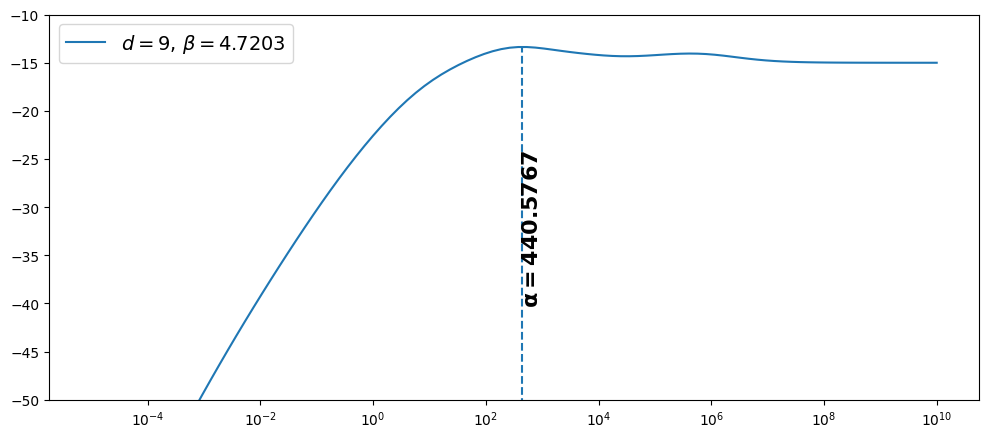

In [7]:
aas = np.logspace(-5, 10, 100)

evids = [lr_log_marginal(xd_d, data, d1, alpha=a, beta=betas[-1]) for a in aas]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(111)
ax.set_xscale('log')
ax.plot(aas, evids, label=r'$d=%d$, $\beta=%.4f$' % (d1, betas[-1]))
ax.vlines(alphas[-1], -70, lr_log_marginal(xd_d, data, d1, alpha=alphas[-1], beta=betas[-1]), linestyles='--')
ax.text(alphas[-1]+.2, -40, r'$\mathbf{\alpha=%.4f}$' % alphas[-1], rotation=90, fontsize=16, horizontalalignment='left')
# ax.set_xlim((10**(-5), 10**5))
ax.set_ylim((-50, -10))
ax.legend(fontsize=14)

После обучения силы регуляризации мы можем построить соответствующие модели:

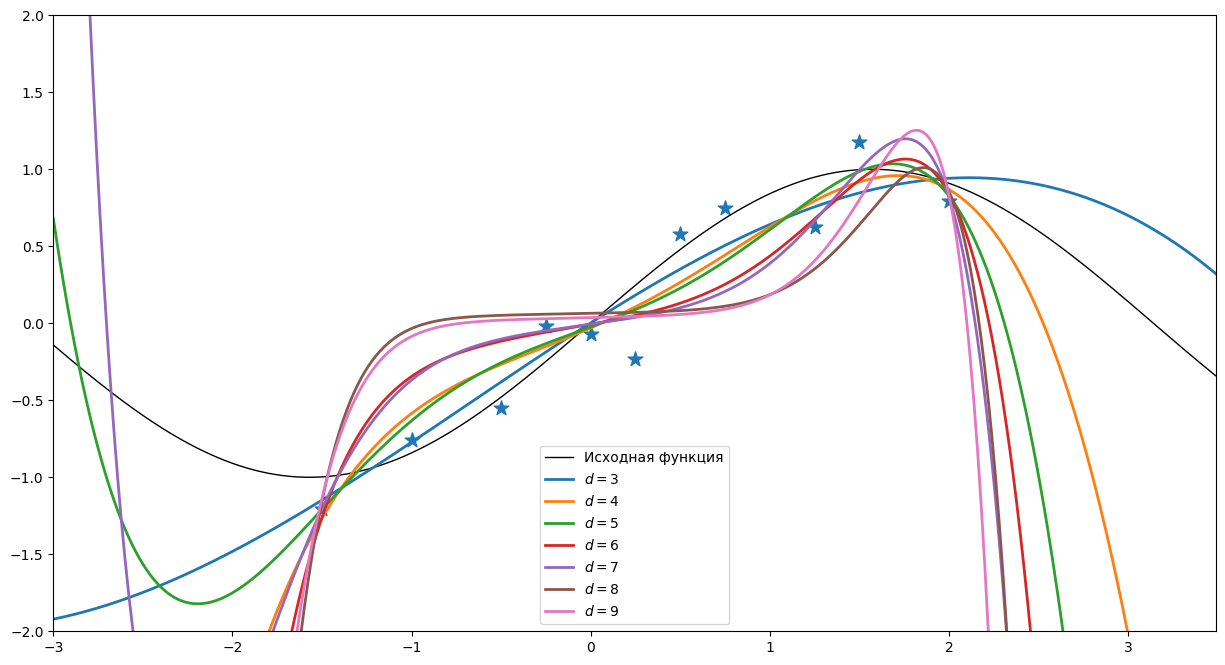

In [8]:
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.set_xlim((xs[0], xs[-1]))
ax.set_ylim((-2, 2))
ax.scatter(xd, data, marker='*', s=120)
ax.plot(xs, orig(xs), linewidth=1, label="Исходная функция", color="black")

set_of_powers = [ 3, 4, 5, 6, 7, 8, 9]

for d in set_of_powers:
    # обучаем гиперпараметры для полинома заданной степени
    alphas, betas, lms = fit_eb(get_X(d), data, max_iter=1000)
    # Обучаем модель с заданными параметрами
    cur_model = train_model(xd_d[:, :d], data, alpha=alphas[-1]/betas[-1])
    ax.plot(xs, cur_model.predict( xs_d[:, :d] ), linewidth=2, label="$d=%d$" % d)
plt.legend()

# Релевантные векторы

Для того, чтобы подойти к методу релевантных векторов надо снова вернуться к эмпирическому Байесу в линейной регрессии и рассмотреть более сложный случай априорного распределения.

Правдоподобие одной точки данных выглядит следующим образом:
$$p(y|\overline{w},\overline{x})=N(y|\overline{w}^\top\overline{x},\beta^{-1}),$$

а на параметра вводится априорное распределение:

$$p(\overline{w}|\overline{\alpha})=\prod_{i=1}^dN(w_i|0,\alpha_i^{-1}).$$

Отсюда мы получали апостериорное распределение: $p(\overline{w}|\overline{y},X,\overline{\alpha},\beta)=N(\overline{w}|\overline{\mu},\Sigma)$ с параметрами $\overline{\mu}=\beta\Sigma X^\top\overline{y}$, $\Sigma^{-1}=A^{-1}+\beta X^\top X$.

Отличие от ранее приведённого примера в матрице ковариации априорного распределения. Ранее мы рассматривали скалярную матрицу $\alpha E$, теперь диагональную матрицу $A=\begin{pmatrix}
\alpha_1^{-1} &0&\dots&0\\
0&\alpha_2^{-1}&\dots&0\\
\vdots&\vdots&\ddots&\vdots\\
0&0&\dots&\alpha_d^{-1}
\end{pmatrix}$.

То есть у каждой компоненты вектора $\overline{w}$ своё априорное распределение. 

Далее мы также ставим задачу максимизации маргинального правдоподобия $p(\overline{y}|X,\overline{\alpha},\beta)\rightarrow\max_{\beta,\overline{\alpha}}$.

В результате мы получим следующие итеративные формулы для параметров $\overline{\alpha}$ и $\beta$:

$$\alpha_i=\frac{\gamma_i}{\mu_i^2}, \;\; \beta=\frac{N-\sum\limits_{j=1}^d\gamma_j}{(\overline{y}-X\overline{\mu})^\top(\overline{y}-X\overline{\mu})}, \;\; \gamma_i=1-\alpha_i-\Sigma_{ii}, \;\; \forall i=\overline{1,d}.$$

И сам результат для линейной регрессии оказывается не очень интересным. Просто для каждого параметра будет своё априорное распределение, а вместе с этим и свой коэффициент регуляризации.

<h2>Определение метода релевантных векторов</h2>

Но если рассмотреть модель, где весов $w$ будет много, то получится что-то интересное. Сделаем для каждой точки данных свой вес. Рассмотрим такую модель: $$y(\overline{x})=\sum_{n=1}^N w_n k(\overline{x}_n,\overline{x}) + b.$$ Эта модель заведомо слишком выразительна и может показаться, что она очень просто переобучится. Но тут как раз надо применить эмпирический Байес. На практике окажется, что многие $\alpha_i$ будут расходиться на бесконечность. Это означает, что параметр $\sigma_i^2$ для веса $w_i$ стремится к $0$, а значит и сам вес будет $0$. 

Можно прийти к следующему алгоритму:
- Необходимо начать итерации для вычисления $\overline{\alpha}$ и $\beta$.
- По мере выполнения итераций отбрасываем $\alpha_i$, уходящие на бесконечность.
- Останавливаемся когда $\alpha_i$ перестанут уходить в бесконечность.

**Метод релевантных векторов** состоит в выполнении описанного алгоритма.

In [9]:
# ! pip install sklearn_rvm

Описанный метод реализован в библиотеке `sklearn_rvm`.

In [10]:
from sklearn.svm import SVC
from sklearn_rvm import EMRVR, EMRVC

Тут мы можем наблюдать процесс обучения параметров $\alpha$. Постепенно некоторые коэффициенты растут, после достижения некоторого порога они отбрасываются и количество опорных векторов уменьшается.

In [11]:
xx, yy = xd, data
dd = {x:y for x,y in zip(xx,yy)}

model = EMRVR(verbose=True, kernel="rbf") # применяем метод релевантных векторов в регрессии
model.fit(xx[:,None], data)

Iteration: 0
Alpha: [0.00198551 0.00323468 0.00549463 0.0035319  0.00461071 0.01370722
 0.00484674 0.02234459 0.00218494 0.03141241 0.14185962 0.00410702]
Beta: 13.375009447117634
Gamma: [0.80695316 0.86581548 0.89280844 0.60426495 0.40909123 0.45556964
 0.43909604 0.44278866 0.55622043 0.59263912 0.66818561 0.86099885]
mu: [-20.15994383  16.36055185 -12.74707274  13.08007867   9.41947792
  -5.7650468   -9.51821496   4.45155951  15.95529805  -4.34354768
  -2.17029708  14.47899937]
Relevance Vectors: 11

Iteration: 1
Alpha: [0.05842074 0.20821609 0.26694268 0.07669864 1.47724923 0.54264346
 0.36489472 1.7044745  0.06944208 0.75861351 5.42174843 0.09867218]
Beta: 10.846968676952121
Gamma: [0.8599211  0.8515796  0.79186153 0.58393777 0.44304115 0.20071908
 0.63105991 0.11007834 0.84129236 0.57618653 0.16206174 0.87303252]
mu: [-3.83659385  2.02234616 -1.72232707  2.75923993  0.54763998 -0.60818688
 -1.31507799  0.25412985  3.48066421 -0.87150778 -0.17289028  2.97452663]
Relevance Vectors:

/home/ivanbalashov/LearningMachine/.venv/lib/python3.12/site-packages/sklearn_rvm/em_rvm.py:267: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  warnings.warn("The default value of gamma will change "


Важно отметить, что для сходимости метода опорных векторов может потребоваться большое количество итераций. Для обучения модели на 11 точках потребовалось более 100 итераций.

In [12]:
predicted_y, predicted_std = model.predict(xs.reshape(-1,1), return_std=True)

Метод релевантных векторов даёт нам предсказательное распределение, тем самым он позволяет оценить дисперсию наших предсказаний.

2 релевантных векторов


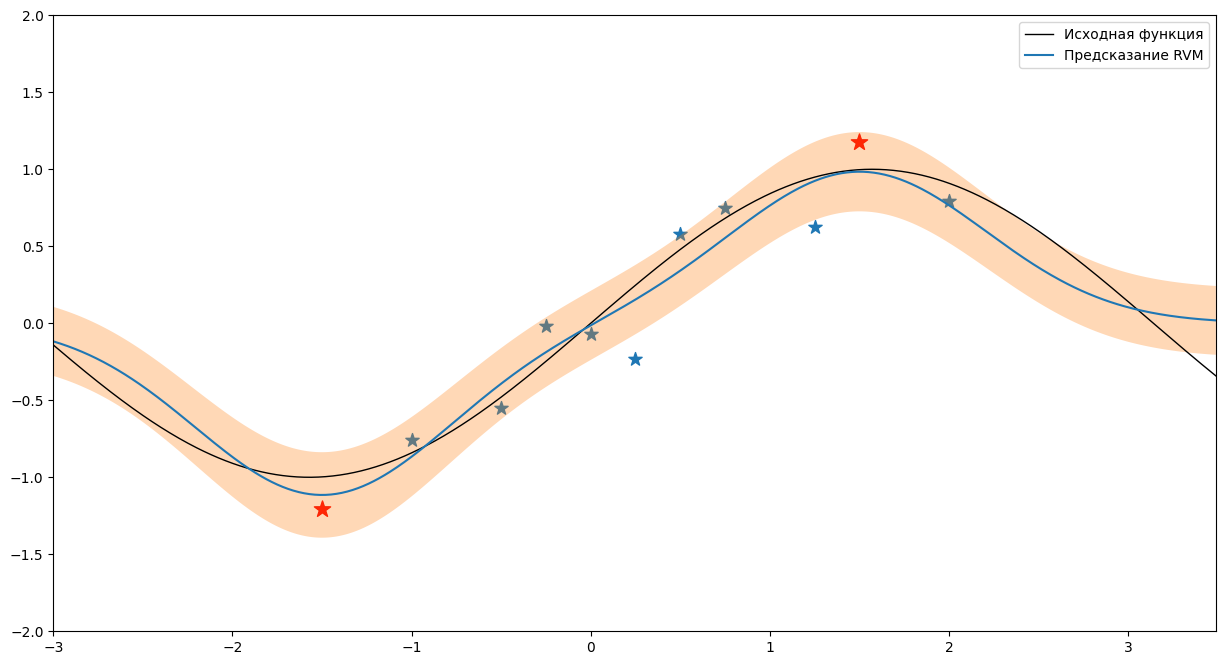

In [13]:
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
print("%d релевантных векторов" % model.relevance_vectors_.shape[0])
ax.set_xlim((xs[0], xs[-1]))
ax.set_ylim((-2, 2))
ax.scatter(xx, yy, marker='*', s=100)
ax.plot(xs, orig(xs), linewidth=1, label="Исходная функция", color="black")
ax.scatter( [ x[0] for x in model.relevance_vectors_], [dd[x[0]] for x in model.relevance_vectors_ ], color='red', marker='*', s=150 )
ax.plot( xs, predicted_y, label="Предсказание RVM" )
ax.fill_between(xs, predicted_y-predicted_std, predicted_y+predicted_std,  alpha=.3)
ax.legend()
plt.show()

А теперь сравним работу Метода опорных и релевантных векторов в классификации.

In [14]:
def sample_mixture(N, pi, mu1, sigma1, mu2, sigma2):
    z = np.array( np.random.rand(N) < pi, dtype=int)
    res = np.zeros((N, 2))
    res[np.where(z == 1)] = np.random.multivariate_normal(mu1, sigma1, np.sum(z))
    res[np.where(z == 0)] = np.random.multivariate_normal(mu2, sigma2, N-np.sum(z))
    return z, res

from matplotlib import colors
cmap = colors.LinearSegmentedColormap(
    'red_blue_classes',
    {'red': [(0, 1, 1), (1, 0.7, 0.7)],
     'green': [(0, 0.7, 0.7), (1, 0.7, 0.7)],
     'blue': [(0, 0.7, 0.7), (1, 1, 1)]})

def get_meshgrid(nx=200, ny=200):
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    return np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))

def plot_colormesh(ax, model):
    xx, yy = get_meshgrid()
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, 1].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap=cmap,
                   norm=colors.Normalize(0., 1.), zorder=0)
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='white')

def plot_colormesh_svm(ax, model):
    xx, yy = get_meshgrid()
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, cmap=cmap,
                   norm=colors.Normalize(0., 1.), zorder=0)
    ax.contour(xx, yy, Z, [-1, 0, 1], linewidths=2., colors='white', linestyles=['--', '-', '--'])

def plot_points(ax, x, z, mus=None, mu1=None, mu2=None, sigmas=None, points_alpha=1.0, colors=['r', 'b', 'g', 'magenta', 'grey', 'purple', 'darkgreen']):
    print(set(z))
    for i in set(z):
        ax.scatter(x[np.where(z==i), 0], x[np.where(z==i), 1], marker='.', color=colors[i % 7], alpha=points_alpha)
    if mus is not None:
        for i in range(mus.shape[0]):
            ax.scatter([mus[i, 0]], [mus[i, 1]], marker='*', s=200, color=colors[i % 7])
    if mu1 is not None:
        for i in range(mu1.shape[0]):
            ax.scatter([mu1[i, 0]], [mu1[i, 1]], marker='*', s=200, color=colors[0])
    if mu2 is not None:
        for i in range(mu2.shape[0]):
            ax.scatter([mu2[i, 0]], [mu2[i, 1]], marker='*', s=200, color=colors[1])

def sample_mixtures(mu0=np.array([ [-1,-1], [1,1] ]), sigma0=2, k=5, pi=0.5, df=4, N=200, Ntest=None):
    z = np.array( np.random.rand(N) < pi, dtype=int)
    res = np.zeros((N, 2))
    mus, sigmas = [], []
    for i, n in zip(range(2), [N-np.sum(z), np.sum(z)]):
        mus.append( np.random.multivariate_normal(mu0[i], sigma0 * np.identity(2), k) )
        sigmas.append( scipy.stats.invwishart.rvs(df, np.identity(2), size=k) )
        mixture_ind = np.random.randint(k, size=n)
        cur_res = np.zeros((n, 2))
        for j in range(k):
            cur_indices = np.where(mixture_ind == j)[0]
            cur_res[cur_indices] = np.random.multivariate_normal(mus[-1][j], sigmas[-1][j], len(cur_indices))
        res[np.where(z == i)] = cur_res
    return z, res, mus, sigmas



{np.int64(0), np.int64(1)}


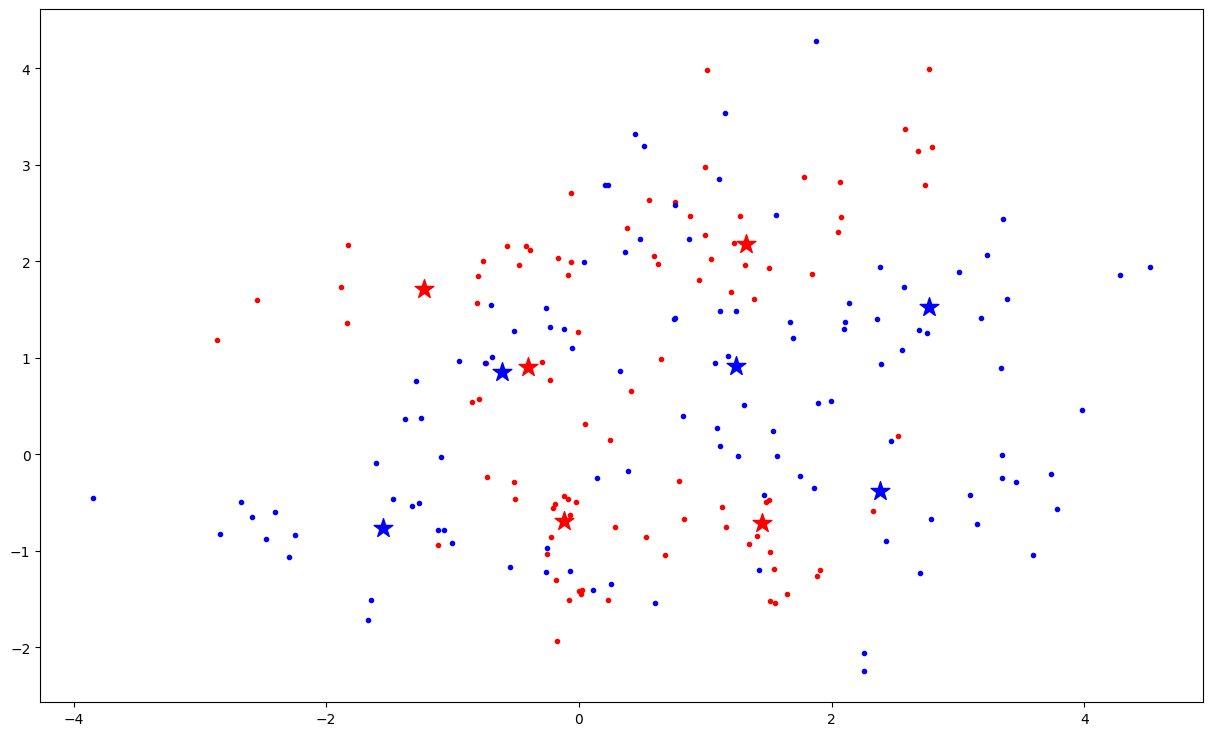

In [15]:
np.random.seed(45)
z, x, mus, sigmas = sample_mixtures(k=5, sigma0=5, N=200)

fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(111)
plot_points(ax, x, z, mu1=mus[0], mu2=mus[1])
plt.show()

На примере классификации легко увидеть, что релевантные векторы получают намного меньше опорных векторов. А это означает более низкую вычислительную сложность при применении модели в будущем. 

Причём RVM даёт нам оценки вероятностей, а SVM не даёт, что может быть важно на практике.

/home/ivanbalashov/LearningMachine/.venv/lib/python3.12/site-packages/sklearn_rvm/em_rvm.py:675: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  warnings.warn("The default value of gamma will change "


10 релевантных векторов
{np.int64(0), np.int64(1)}


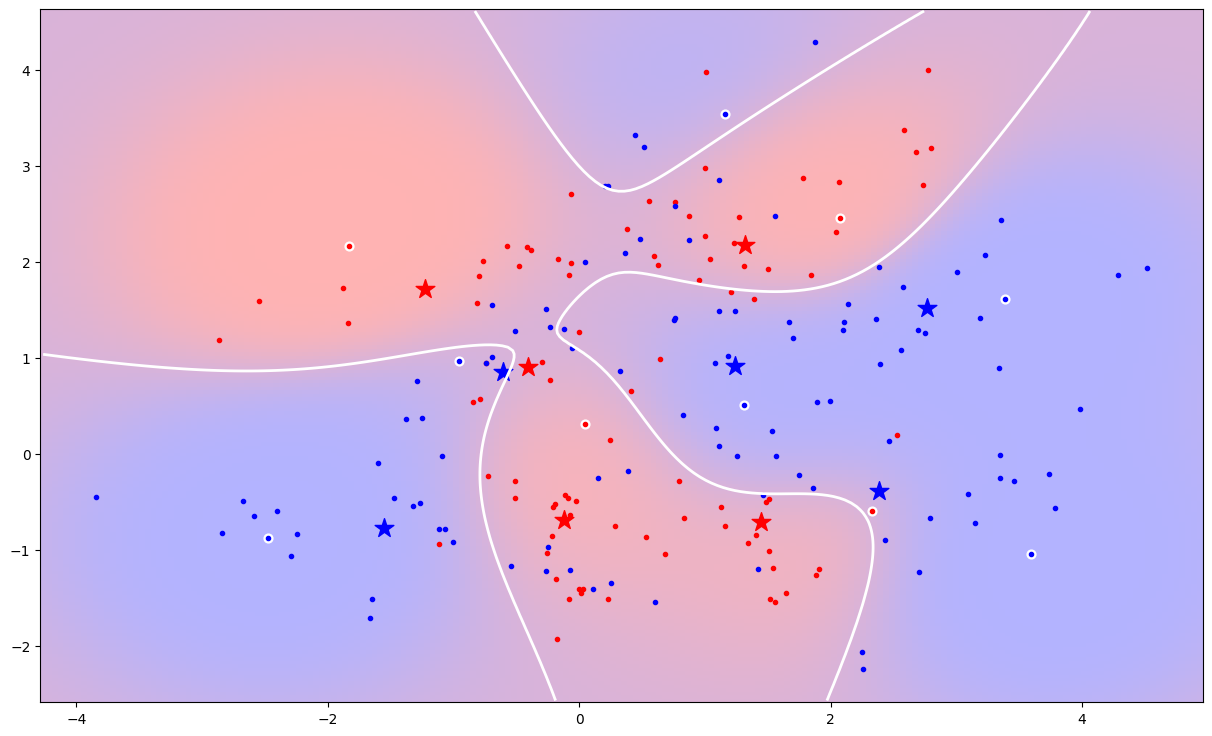

In [16]:
model = EMRVC(kernel="rbf", n_iter_posterior=6).fit(x, z)
fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(111)
print("%d релевантных векторов" % model.relevance_vectors_.shape[0])
ax.scatter( model.relevance_vectors_[:, 0], model.relevance_vectors_[:, 1], color='white', s=40 )
plot_points(ax, x, z, mu1=mus[0], mu2=mus[1])
plot_colormesh(ax, model)
plt.show()

А что более важно $-$ у метода релевантных векторов нет гиперпараметров, потому что эти гиперпараметры мы как раз и обучаем. Остаётся только выбрать вид ядра. 

Недостатком метода релевантных векторов является долгое обучение, но это нивелируется необходимостью длительного обучения гиперпараметров в методе опорных векторов. 

В целом же можно заключить, что метод релевантных векторов это лучшая версия метода опорных векторов.

116 опорных векторов
{np.int64(0), np.int64(1)}


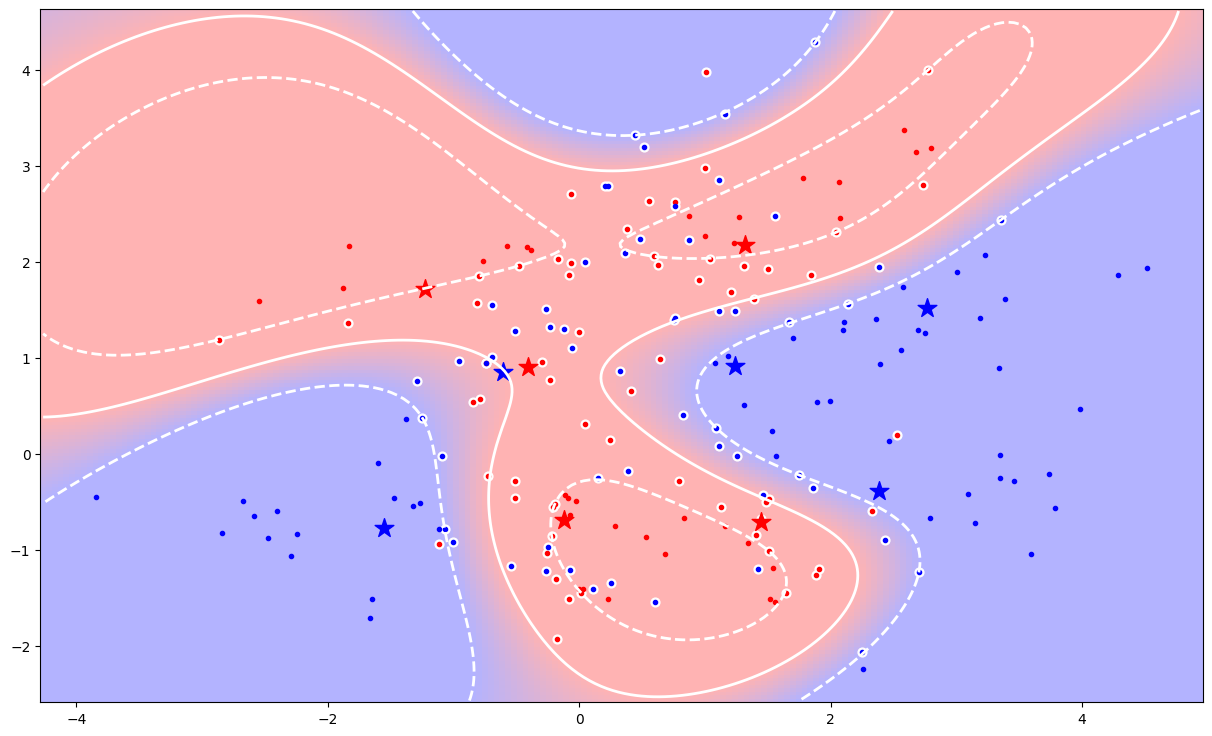

In [17]:
model_svm = SVC(kernel="rbf", C=1e1).fit(x, z)

fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(111)
print("%d опорных векторов" % model_svm.support_vectors_.shape[0])
ax.scatter( model_svm.support_vectors_[:, 0], model_svm.support_vectors_[:, 1], color='white', s=40 )
plot_points(ax, x, z, mu1=mus[0], mu2=mus[1])
plot_colormesh_svm(ax, model_svm)
plt.show()

### Многоклассовая классификация с методом релевантных векторов

Поскольку метод релевантных векторов выводится из логистической регрессии, то нет никаких препятствий к тому, чтобы обобщить метод на случай нескольких классов. К сожалению, из-за малой популярности метода релевантных векторов, на данный момент такой реализации "из коробки" нет.

В библиотеке `sklearn-rvm` многоклассовая классификация реализована через сведение к бинарной классификации по стратегии one vs. rest.

# Обобщённые линейные модели

Ранее линейными моделями мы называли линейную регрессию и логистическую регрессию. У них есть что-то общее. Предсказания мы строили следующим образом:

В линейной регрессии: $y(\overline{x})=\overline{w}^\top\overline{x}$.

В логистической регрессии: $y(\overline{x})=\sigma(\overline{w}^\top\overline{x})$.

Обе эти модели объединяет то, что предсказание строится как некоторая функция от линейной комбинации входов. 

Мы можем рассмотреть более широкий класс моделей $y(\overline{x})=h(\overline{w}^\top\overline{x})$. Интерес вызывает вид функции $h$, называемой обратной функцией связи (inverse link function). А точнее даже не сама функция, а распределение $y$, связанное с этой функцией.

## Пуассоновская регрессия

Распределение пуассона обычно возникает, когда речь идёт о количестве независимых событий, которые происходят за некоторый промежуток времени. Предположим, что $y$ имеет именно такой смысл.

Распределение Пуассона имеет вид: $p(y|\mu)=\frac{1}{y!}\mu^ye^{-\mu}$, где $\mu$ $-$ это среднее этого распределения, по смыслу $\mu$ соответствует средней интенсивности событий.

Поскольку $\mu$ имеет строго положительные значения, то моделировать $\mu=\overline{w}^\top\overline{x}$ будет плохо, естественно моделировать $\mu$ как экспоненту: $\mu=e^{\overline{w}^\top\overline{x}}$ или $\log\mu=\overline{w}^\top\overline{x}$. Тогда можно посчитать логарифм правдоподобия и решить задачу методом максимизации правдоподобия: $$\log p(y|\overline{x},\overline{w})=y\overline{w}^\top\overline{x}-e^{\overline{w}^\top\overline{x}}-\log(y!).$$

Далее это уже можно оптимизировать градиентным спуском или методом второго порядка.

В качестве примера рассмотрим набор данных о мигрирующих в Эдинбург подмастерьях.

В нём содержатся столбцы:

- `Dist` - Расстояние до Эдинбурга
- `Apps` - Число подмастерий
- `Pop` - Население (тыс.)
- `Urban` - Степень урбанизации
- `Locn` - Направление откуда происходит миграция относительно Эдинбурга. Принимаемые значения: север, юг или запад. Восточнее Эдинбурга находиться море.

Мы пройдём по стопам авторов [оригинальной статьи](https://doi.org/10.1111/j.0033-0124.1989.00190.x), где рассматривалось применение Пуассоновской регрессии для данного набора данных.

In [18]:
# ! unzip apprentice.zip

In [19]:
from sklearn.preprocessing import OneHotEncoder
import scipy.stats as st
import statsmodels.api as sm
    
df = pd.read_csv("apprentice.csv")
df.head()

,County,Dist,Apps,Pop,Urban,Locn
0,Midlothian,21,225,56,18.8,S
1,Ayr,110,2,84,26.4,W
2,West Lothian,24,22,18,37.9,W
3,Kircudbright,110,0,29,11.3,S
4,East Lothian,33,44,30,43.4,S


In [20]:

X = np.hstack([df[["Dist", "Pop", "Urban"]].to_numpy(), 
               OneHotEncoder().fit_transform(df["Locn"].to_numpy()[:,None]).toarray()])
y = df["Apps"].to_numpy()

Мы можем попытаться описать данные с помощью простого распределения пуассона, но у нас не получится. И ситуация не изменится, даже если мы выкинем очевидный выброс.

(0.0, 225.0)

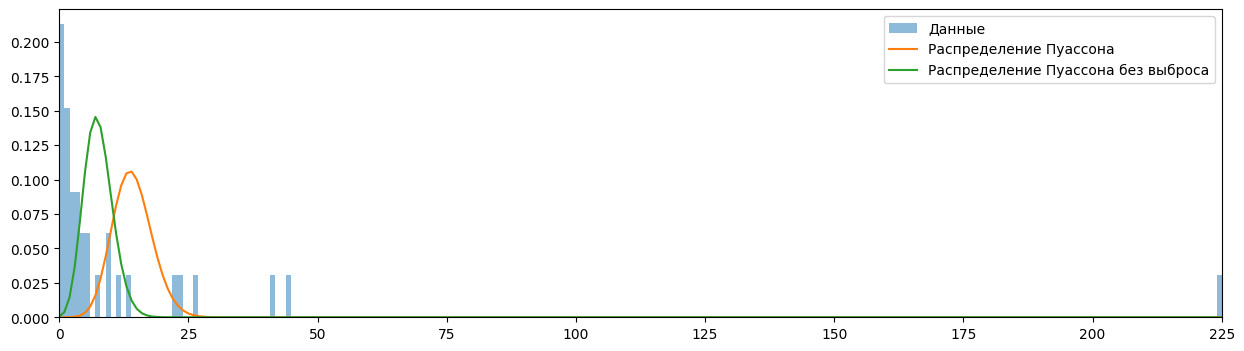

In [21]:
lmb1 = np.mean(y)
lmb2 = np.mean(y[1:])

fig = plt.figure(figsize=(figsize[0], figsize[1]/2))
ax = fig.add_subplot(111)
xs = np.arange(0, 250)
ax.hist(y, bins=226, linewidth=0.1, density=True, alpha=0.5, label="Данные")
ax.plot(xs, st.poisson.pmf(xs, lmb1), linewidth=1.5, label="Распределение Пуассона")
ax.plot(xs, st.poisson.pmf(xs, lmb2), linewidth=1.5, label="Распределение Пуассона без выброса")

ax.legend(loc="upper right")
ax.set_xlim(0, 225)

А не получается не потому что распределение не то, а потому что у каждого наблюдения свой параметр интенсивности. Интенсивность миграции очевидно зависит от расстояния,  количества населения и степени урбанизации. 

Попробуем обучить пуассоновскую регрессию на разных наборах имеющихся признаков.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       31
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -244.15
Date:                Thu, 07 May 2026   Deviance:                       393.96
Time:                        11:09:11   Pearson chi2:                     482.
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.7936      0.337     35.014      0.0

(0.0, 235.0)

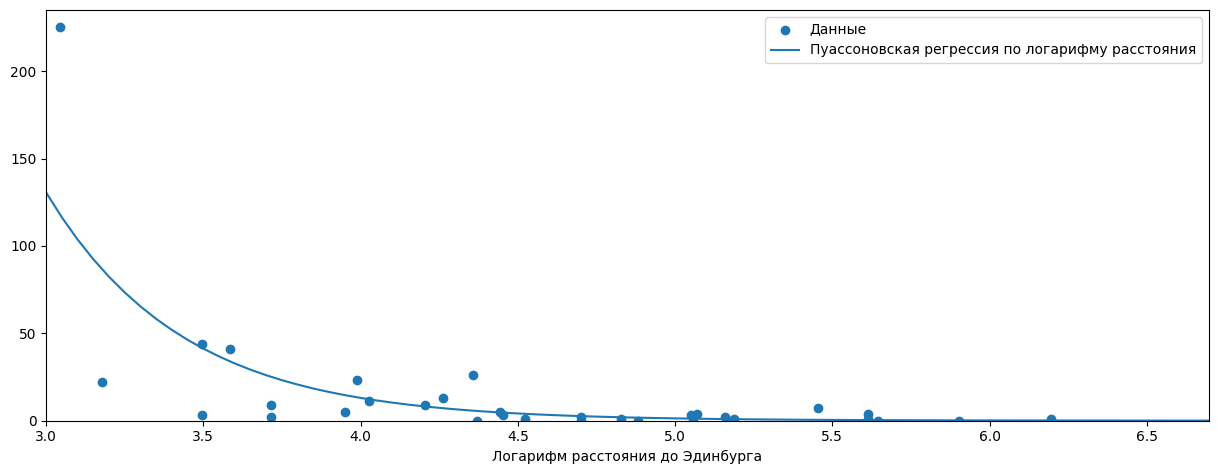

In [22]:
data = np.log(X[:, 0])
xmax, xs = np.max(data)+.5, np.arange(1, np.max(data)+1, 0.05)
model_poisson = sm.GLM(y, sm.add_constant(data, prepend=True), family=sm.families.Poisson()).fit()
print(model_poisson.summary())
fig = plt.figure(figsize=(figsize[0], figsize[1]/1.5))
ax = fig.add_subplot(111)
preds = model_poisson.predict(sm.add_constant(xs, prepend=True))
ax.scatter(data, y, label="Данные")
ax.plot(xs, preds, linewidth=1.5, label="Пуассоновская регрессия по логарифму расстояния")
ax.legend(loc="upper right")
ax.set_xlabel("Логарифм расстояния до Эдинбурга")
ax.set_xlim(3, xmax)
ax.set_ylim(0, np.max(y)+10)

Мы видим довольно ожидаемый результат. Наблюдается отрицательная зависимость от расстояния. Также мы видим большой разброс предсказаний (Deviation: 393).

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       31
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -656.05
Date:                Thu, 07 May 2026   Deviance:                       1217.8
Time:                        11:09:12   Pearson chi2:                 2.88e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9821
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3203      0.651     -6.640      0.0

(8.267193191416238, 12.148187865760873)

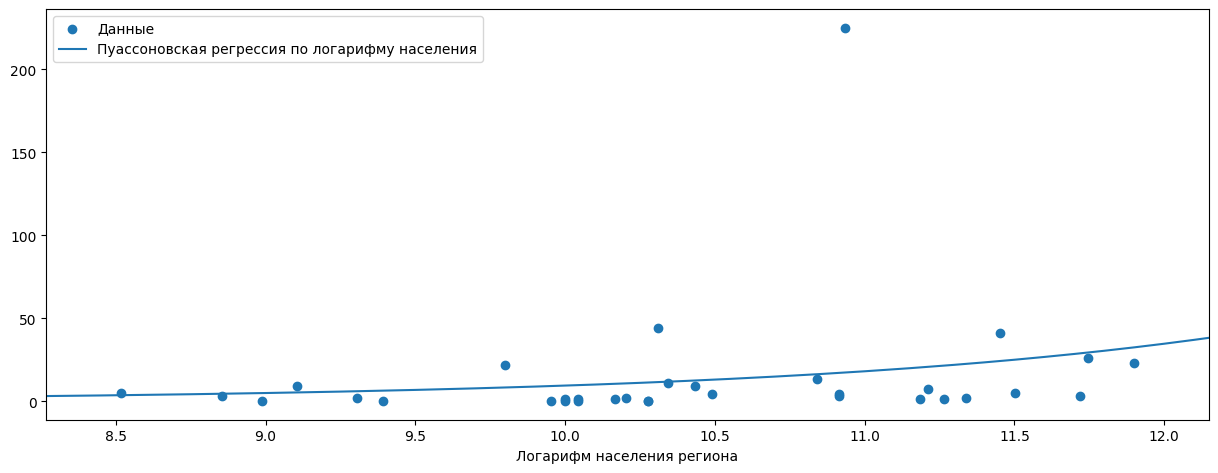

In [23]:
data = np.log(X[:, 1]*1000)
xmax, xs = np.max(data), np.arange(0.1, np.max(data)+.3, 0.05)
model_poisson = sm.GLM(y, sm.add_constant(data, prepend=True), family=sm.families.Poisson()).fit()
print(model_poisson.summary())
fig = plt.figure(figsize=(figsize[0], figsize[1]/1.5))
ax = fig.add_subplot(111)
preds = model_poisson.predict(sm.add_constant(xs, prepend=True))
ax.scatter(data, y, label="Данные")
ax.plot(xs, preds, linewidth=1.5, label="Пуассоновская регрессия по логарифму населения")
ax.legend(loc="upper left")
ax.set_xlabel("Логарифм населения региона")
ax.set_xlim(np.min(data)-.25, xmax+.25)

От количества населения мы видим также ожидаемую положительную зависимость.

In [24]:
data = np.hstack([np.log(X[:,0]).reshape(-1, 1), np.log(X[:,1]*1000).reshape(-1, 1), np.log(X[:,2] / (100 - X[:,2])).reshape(-1, 1), X[:,3:]])
Xdf = pd.DataFrame(data,
                   columns=["Log distance", "Log population", "Logit urbanization", "North", "West", "South"])
model_poisson = sm.GLM(y, sm.add_constant(Xdf, prepend=True), family=sm.families.Poisson())
res = model_poisson.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       27
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86.710
Date:                Thu, 07 May 2026   Deviance:                       79.073
Time:                        11:09:13   Pearson chi2:                     90.1
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1780      0

И наконец при регрессии по 6 признакам мы везде видим ожидаемые результаты: по расстоянию (Log distance) и коэффициенту урбанизации (Logit urbanization) коэффициенты отрицательные, а по населению (Log population) положительный. Модель, однако, всё ещё не слишком хорошо описывает данные.

Кстати, про урбанизацию. При обучении модели мы выполнили логит-преобразование показателя урбанизации. Это сделано потому, что степень урбанизации выражена в процентах (ограничена интервалом $[0,100]$), тогда как линейная модель предполагает работу с неограниченными по диапазону признаками. То есть мы применили функцию, обратную сигмоиде: $\sigma^{-1}\left(\frac{u}{100}\right) = \log\left(\frac{u}{100-u}\right)$.


На этом авторы статьи не останавливаются. Они предлагают добавить в рассматриваемые признаки взаимодействия между признаками. Конкретно авторы предлагают добавить признаки, соответствующие логарифму расстояния в каждом направлении.

In [25]:
data2 = np.hstack( [data, data[:, 3:] * data[:, 0].reshape(-1, 1)] )
Xdf = pd.DataFrame(data2,
                   columns=["Log distance", "Log population", "Logit urbanization", "North", "West", "South", "Log dist North", "Log dist West", "Log dist South"])
model_poisson = sm.GLM(y, sm.add_constant(Xdf, prepend=True), family=sm.families.Poisson())
res = model_poisson.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       25
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -73.068
Date:                Thu, 07 May 2026   Deviance:                       51.789
Time:                        11:09:13   Pearson chi2:                     46.2
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6305      0

На тренировочном наборе данных разброс уменьшается, но чтобы действительно судить о пользе добавления новых признаков необходимо проверять модель на тестовой выборке.

In [26]:
from sklearn.model_selection import train_test_split

def one_experiment(X, y, get_datadf):
    X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.1)
    model_poisson = sm.GLM(y_train, get_datadf(X_train), family=sm.families.Poisson()).fit()
    predictions = model_poisson.predict(get_datadf(X_test))
    return np.sqrt(np.mean((predictions - y_test) ** 2))

Функции для создания разных наборов признаков:

In [27]:
def data_id(data):
    return data

def data_distance(data): # взаимодействия направления и расстояния
    x = np.hstack( [data, data[:, 3:] * data[:, 0].reshape(-1, 1) ] )
    return pd.DataFrame(x,
                   columns=["Log distance", "Log population", "Logit urbanization", "North", "West", "South", "Log dist North", "Log dist West", "Log dist South"])

def data_all_interactions(data): # все взаимодействия с направлениями
    x = np.hstack( [data, data[:, 3:] * data[:, 0].reshape(-1, 1), data[:, 3:] * data[:, 1].reshape(-1, 1), data[:, 3:] * data[:, 2].reshape(-1, 1)] )
    return pd.DataFrame(x,
                   columns=["Log distance", "Log population", "Logit urbanization", "North", "West", "South", "Log dist North", "Log dist West", "Log dist South", "Log pop North", "Log pop West", "Log pop South", "Logit urb North", "Logit urb West", "Logit urb South"])

Предсказания на логарифме расстояния:

In [28]:
np.mean( [ one_experiment(data[:, :1], y, data_id) for _ in range(5000) ] )

np.float64(25.550334213999044)

Предсказания на логарифме расстояния и населения:

In [ ]:
np.mean( [ one_experiment(data[:, :2], y, data_id) for _ in range(5000) ] )

Предсказания на основании всех имеющихся признаков:

In [ ]:
np.mean( [ one_experiment(data, y, data_id) for _ in range(5000) ] )

7.840171255804482

Предсказания на основании всех имеющихся признаков и взаимодействия направления и расстояния:

In [ ]:
np.mean( [ one_experiment(data, y, data_distance) for _ in range(5000) ] )

45.63835799912052

По сделанным экспериментам можно судить, что надо остановиться на рассмотрении всех признаков без взаимодействий.

## Отрицательная биномиальная регрессия

У распределения Пуассона есть недостаток: его дисперсия совпадает с средним, поэтому оно не всегда может идеально описать данные. 

Отрицательное биномиальное распределение похоже своим видом на распределение Пуассона и может помочь нам решить проблему. Распределение имеет вид:
$$\text{NegBinom}(k|r,p)=\begin{pmatrix}k+r-1\\r-1\end{pmatrix}(1-p)^kp^r.$$

Мы легко можем обучить отрицательное биномиальное распределение на наших данных.

In [ ]:
nb = sm.NegativeBinomial(y, np.ones_like(y)).fit()
nb2 = sm.NegativeBinomial(y[1:], np.ones_like(y[1:])).fit()

def nb_params(model):
    mu = np.exp(model.params[0])
    p = 1 / (1 + mu * model.params[1])
    n = mu * p / (1 - p)
    return n, p, mu

n, p, mu = nb_params(nb)
n2, p2, mu2 = nb_params(nb2)

Optimization terminated successfully.
         Current function value: 3.305411
         Iterations: 7
         Function evaluations: 10
         Gradient evaluations: 10
Optimization terminated successfully.
         Current function value: 2.977905
         Iterations: 5
         Function evaluations: 6
         Gradient evaluations: 6


Если просто обучить распределение, то уже видно, что оно очень похоже на имеющиеся данные.

(0.0, 225.0)

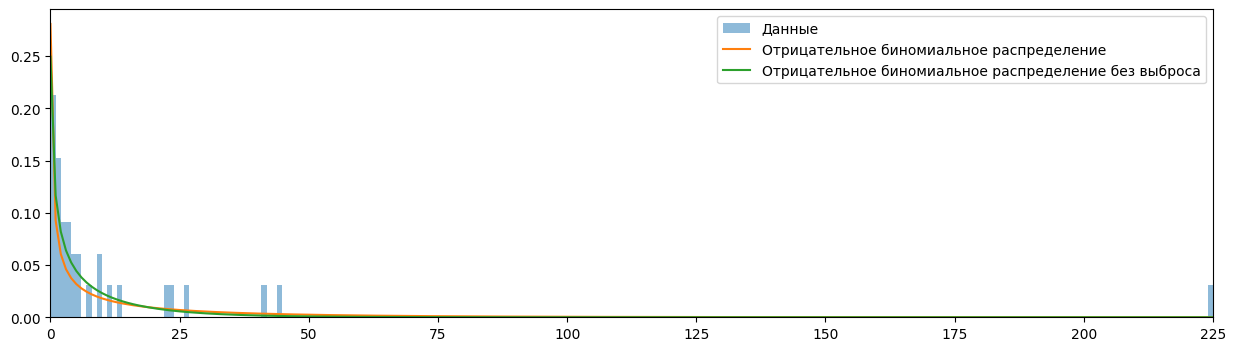

In [ ]:
fig = plt.figure(figsize=(figsize[0], figsize[1]/2))
ax = fig.add_subplot(111)
xs = np.arange(0, 250)
ax.hist(y, bins=226, linewidth=0.1, density=True, alpha=0.5, label="Данные")
ax.plot(xs, st.nbinom.pmf(xs, n, p), linewidth=1.5, label="Отрицательное биномиальное распределение")
ax.plot(xs, st.nbinom.pmf(xs, n2, p2), linewidth=1.5, label="Отрицательное биномиальное распределение без выброса")

ax.legend(loc="upper right")
ax.set_xlim(0, 225)

При использовании всего одного признака мы видим намного меньшую дисперсию (разница в 10 раз).

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       31
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -94.649
Date:                Mon, 02 Mar 2026   Deviance:                       39.566
Time:                        23:01:05   Pearson chi2:                     36.6
No. Iterations:                    11   Pseudo R-squ. (CS):             0.8053
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0155      1.180      7.638      0.0

d:\envs\main\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


(0.0, 235.0)

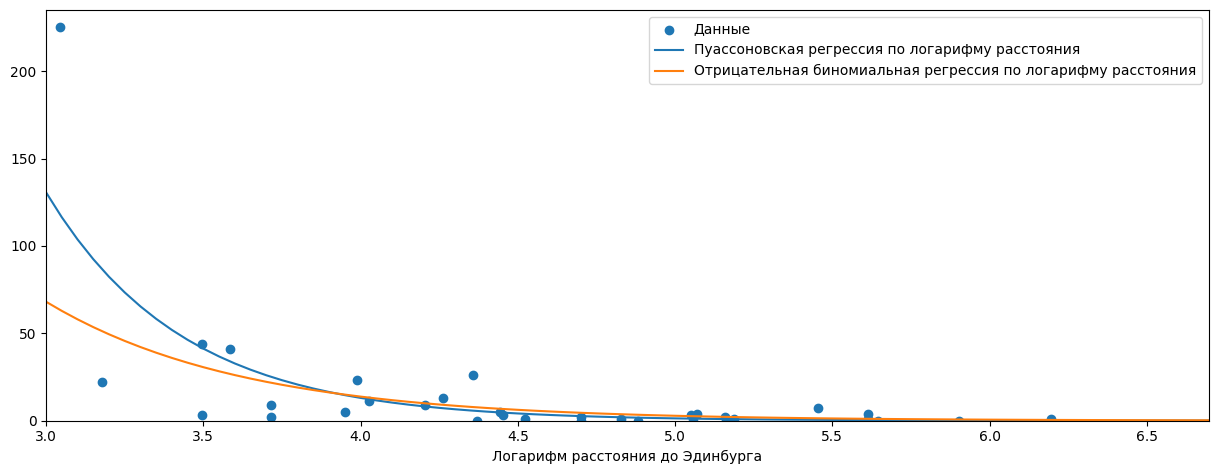

In [ ]:
data = np.log(X[:, 0])
xmax, xs = np.max(data)+.5, np.arange(1, np.max(data)+1, 0.05)
model_poisson = sm.GLM(y, sm.add_constant(data, prepend=True), family=sm.families.Poisson()).fit()
model_nb = sm.GLM(y, sm.add_constant(data, prepend=True), family=sm.families.NegativeBinomial()).fit()
print(model_nb.summary())
fig = plt.figure(figsize=(figsize[0], figsize[1]/1.5))
ax = fig.add_subplot(111)
preds = model_poisson.predict(sm.add_constant(xs, prepend=True))
preds_nb = model_nb.predict(sm.add_constant(xs, prepend=True))
ax.scatter(data, y, label="Данные")
ax.plot(xs, preds, linewidth=1.5, label="Пуассоновская регрессия по логарифму расстояния")
ax.plot(xs, preds_nb, linewidth=1.5, label="Отрицательная биномиальная регрессия по логарифму расстояния")
ax.legend(loc="upper right")
ax.set_xlabel("Логарифм расстояния до Эдинбурга")
ax.set_xlim(3, xmax)
ax.set_ylim(0, np.max(y)+10)

In [ ]:
data = np.hstack([np.log(X[:,0]).reshape(-1, 1), np.log(X[:,1]*1000).reshape(-1, 1), np.log(X[:,2] / (100 - X[:,2])).reshape(-1, 1), X[:,3:]])
Xdf = pd.DataFrame(data,
                   columns=["Log distance", "Log population", "Logit urbanization", "North", "West", "South"])
xmax, xs = np.max(data), np.arange(0.1, np.max(data)+.3, 0.05)
model_nb = sm.GLM(y, sm.add_constant(Xdf, prepend=True), family=sm.families.NegativeBinomial(alpha=1.0)).fit()
data = np.hstack([np.log(X[:,0]).reshape(-1, 1), np.log(X[:,1]*1000).reshape(-1, 1), np.log(X[:,2] / (100 - X[:,2])).reshape(-1, 1), X[:,3:]])
print(model_nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   33
Model:                            GLM   Df Residuals:                       27
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -85.570
Date:                Mon, 02 Mar 2026   Deviance:                       21.408
Time:                        23:01:05   Pearson chi2:                     16.7
No. Iterations:                    12   Pseudo R-squ. (CS):             0.8877
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0993      2

In [ ]:
def one_experiment_nb(X, y, get_datadf):
    X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.1)
    model_poisson = sm.GLM(y_train, get_datadf(X_train), family=sm.families.NegativeBinomial(alpha=1.0)).fit()
    predictions = model_poisson.predict(get_datadf(X_test))
    return np.sqrt(np.mean((predictions - y_test) ** 2))

data = np.hstack([np.log(X[:,0]).reshape(-1, 1), np.log(X[:,1]*1000).reshape(-1, 1), np.log(X[:,2] / (100 - X[:,2])).reshape(-1, 1), X[:,3:]])

Правда, в экспериментах с тестовой выборкой показатели хуже чем у Пуассоновской регрессии.

In [ ]:
np.mean( [ one_experiment_nb(data[:, :1], y, data_id) for _ in range(5000) ] )

39.94615130402037

In [ ]:
np.mean( [ one_experiment_nb(data[:, :2], y, data_id) for _ in range(5000) ] )

15.452885809895594

In [ ]:
np.mean( [ one_experiment_nb(data, y, data_id) for _ in range(5000) ] )

11.582848596717092

In [ ]:
np.mean( [ one_experiment_nb(data, y, data_distance) for _ in range(5000) ] )

153.17522824905222

# Домашнее задание

- Примените метод релевантных векторов к Ирисам Фишера. Используйте разные ядра, с помощью кросс-валидации подберите параметры. Сравните результат с результатом, полученным для SVM на прошлом занятии.

- Выберите некоторую одномерную нелинейную зависимость в задаче регрессии. Сгенерируйте выборку. Примените метод релевантных и метод опорных векторов. Сравните количество опорных(релевантных) векторов и сравните качество моделей на тестовой выборке.